In [1]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
#reading the dataset to the python environment
df=pd.read_csv('/content/drive/MyDrive/IIT Palakkad Advanced AI/StudentsPerformance.csv')
#displaying the first few rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group C,some high school,free/reduced,none,0,17,10
1,female,group B,high school,free/reduced,none,8,24,23
2,female,group B,some high school,free/reduced,none,18,32,28
3,female,group B,some college,standard,none,11,38,32
4,female,group C,some college,free/reduced,none,22,39,33


In [3]:
#to find the number of rows and shape
print('Shape of dataset: ',df.shape)

Shape of dataset:  (1000, 8)


1. 1. Calculate the mean, median, and mode for the math, reading, and writing scores.


In [4]:
#columns to analyze
score_columns =["math score","reading score","writing score"]

#looping through each column to calculate the statistics
for col in score_columns:
  print("\nStatistics for",col,":")

  mean_val = df[col].mean()
  median_val = df[col].median()
  mode_val = df[col].mode()[0]

  print("Mean : ",mean_val)
  print("Median : ",median_val)
  print("Mode : ",mode_val)


Statistics for math score :
Mean :  66.001
Median :  66.0
Mode :  65

Statistics for reading score :
Mean :  69.195
Median :  70.0
Mode :  72

Statistics for writing score :
Mean :  68.119
Median :  69.0
Mode :  74


2. Determine the range, variance, and standard deviation for each score category.

In [5]:
#looping through each column to calculate the statistics
for col in score_columns:
  print("\nStatistics for",col,":")

  range = df[col].max() - df[col].min()
  variance = df[col].var()
  std_dev = df[col].std()

  print("Range : ",range)
  print("Variance : ",round(variance,3))
  print("Standard deviation : ",round(std_dev,3))


Statistics for math score :
Range :  100
Variance :  242.411
Standard deviation :  15.57

Statistics for reading score :
Range :  83
Variance :  216.279
Standard deviation :  14.706

Statistics for writing score :
Range :  90
Variance :  231.843
Standard deviation :  15.226


3. Identify the mean, median, and mode of math scores for students with different
parental education levels.

In [6]:
grouped_stats = df.groupby("parental level of education")["math score"].agg(
    mean=lambda x: round(x.mean(), 2),
    median=lambda x: round(x.median(), 2),
    mode=lambda x: round(x.mode().iloc[0], 2)
)

print(grouped_stats)

                              mean  median  mode
parental level of education                     
associate's degree           67.98    67.0    65
bachelor's degree            69.29    68.0    63
high school                  61.82    63.0    57
master's degree              70.25    73.0    79
some college                 67.13    68.0    69
some high school             63.13    65.0    59


4. Compare the mean scores of students who took the test preparation course versus
those who didn’t.

In [7]:
mean_scores = df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean().round(2)

print(mean_scores)

                         math score  reading score  writing score
test preparation course                                          
completed                     69.97          74.18          74.68
none                          63.79          66.42          64.46


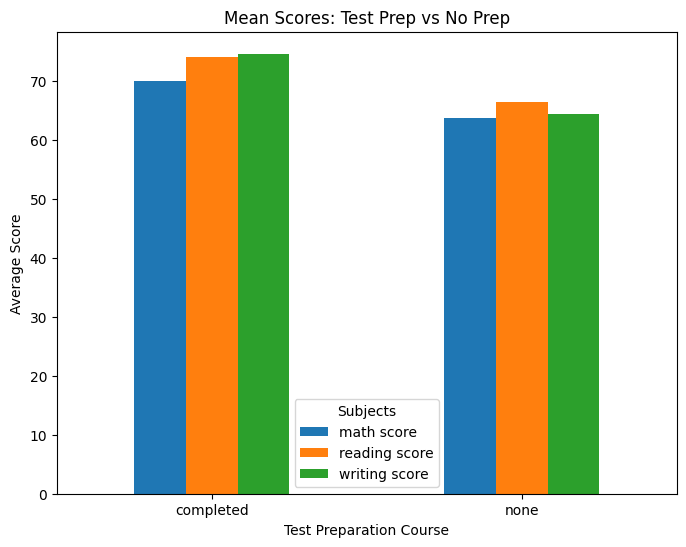

In [8]:
# Plot bar chart
mean_scores.plot(kind="bar", figsize=(8,6))
plt.title("Mean Scores: Test Prep vs No Prep")
plt.ylabel("Average Score")
plt.xlabel("Test Preparation Course")
plt.xticks(rotation=0)
plt.legend(title="Subjects")
plt.show()

The data suggests that test preparation courses positively influence student performance, with the strongest effect seen in writing and reading scores.

5. Calculate the interquartile range (IQR) for each score category.


In [9]:
# Calculate IQR for each score category
for col in score_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = round(Q3 - Q1, 2)

    print(col,": IQR =",IQR)

math score : IQR = 20.0
reading score : IQR = 20.25
writing score : IQR = 21.0


6. Determine the standard deviation for math scores by lunch type (free/reduced vs.
standard).

In [10]:
std_by_lunch = df.groupby("lunch")["math score"].std().round(2)

print(std_by_lunch)

lunch
free/reduced    15.88
standard        13.80
Name: math score, dtype: float64


7. Find the correlation coefficient between math and reading scores, and then between
reading and writing scores.

In [11]:
# Correlation between math and reading scores
corr_math_reading = df["math score"].corr(df["reading score"])

# Correlation between reading and writing scores
corr_reading_writing = df["reading score"].corr(df["writing score"])

print("Correlation (Math vs Reading):",round(corr_math_reading, 3))
print("Correlation (Reading vs Writing):",round(corr_reading_writing, 3))

Correlation (Math vs Reading): 0.815
Correlation (Reading vs Writing): 0.953


8. Interpret the strength and direction of the correlation. What might this suggest about
the relationship between different scores?

Math vs Reading (0.815)

1. This is a strong positive correlation.
2. It suggests that students who perform well in math also tend to perform well in reading, and vice versa
3. This indicates that general academic ability or study habits may influence both subjects.

Reading vs Writing (0.953)

1. This is an extremely strong positive correlation, very close to 1.
2. It indicates that students who excel in reading nearly always excel in writing.

9. Calculate the covariance between math and reading scores. How does it compare
with the correlation? What does it suggest?

In [12]:
# Covariance between math and reading scores
cov_math_reading = df["math score"].cov(df["reading score"])
print("Covariance (Math vs Reading):",round(cov_math_reading, 2))

Covariance (Math vs Reading): 186.6


The covariance between math and reading scores is 186.6, which is positive. This means that when math scores increase, reading scores also tend to increase. Compared with the correlation coefficient of 0.815, the covariance confirms the same direction of the relationship.

10. Z-Test: Assume the national average math score is 50. Use a one-sample z-test to test
if this sample's average math score is significantly different from the national
average.

In [13]:
# Sample mean
sample_mean = df["math score"].mean()

# Population mean (national average)
mu = 50

# Sample standard deviation
sample_std = df["math score"].std()

# Sample size
n = len(df)

# Z-test statistic
z = (sample_mean - mu) / (sample_std / np.sqrt(n))

print("Sample mean:", round(sample_mean, 2))
print("Z-statistic:", round(z, 2))

Sample mean: 66.0
Z-statistic: 32.5


The sample mean of 66.0 is significantly different from the national average of 50. We can confidently reject the null hypothesis and conclude that this sample’s average math score is much higher than the national average.

11. T-Test: Compare the reading scores between students with different lunch types
(free/reduced vs. standard) to test if there is a significant difference.

In [14]:
# Split into two groups based on lunch type
free_reduced = df[df['lunch'] == 'free/reduced']['reading score']
standard = df[df['lunch'] == 'standard']['reading score']

# Perform independent samples t-test (Welch’s t-test by default with equal_var=False)
t_stat, p_value = stats.ttest_ind(free_reduced, standard, equal_var=False)

print("T-statistic:", round(t_stat, 2))
print("P-value:", round(p_value, 4))

# Inference
if p_value < 0.05:
    print("There is a significant difference in reading scores between lunch types.")
else:
    print("No significant difference in reading scores between lunch types.")


T-statistic: -7.31
P-value: 0.0
There is a significant difference in reading scores between lunch types.


12. F-Test: Check if the variances of math scores differ significantly between students
with and without test preparation.

In [15]:
# Split into two groups based on test preparation
prep = df[df['test preparation course'] == 'completed']['math score']
no_prep = df[df['test preparation course'] == 'none']['math score']

# Calculate variances
var_prep = prep.var(ddof=1)
var_no_prep = no_prep.var(ddof=1)

# F-statistic (variance ratio)
F = var_prep / var_no_prep

# Degrees of freedom
df1 = len(prep) - 1
df2 = len(no_prep) - 1

# p-value (two-tailed)
p_value = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))

print("F-statistic:", round(F, 2))
print("P-value:", round(p_value, 4))

# Inference
if p_value < 0.05:
    print("Variances of math scores differ significantly between groups.")
else:
    print("No significant difference in variances of math scores between groups.")


F-statistic: 0.85
P-value: 0.0978
No significant difference in variances of math scores between groups.
